# Notebook 13 — Trends Risk Index v3 (weekly + daily)

Rebuilds the PM-facing risk index on the v3 BSTS posteriors and adds a daily-cadence variant.

**Design call:** the daily Risk Index uses the **weekly-trained** posterior weights (`P(γ=1) · β̄`) applied to the **daily-processed** X matrix. The rolling 5y daily z-score normalizes the cross-cadence regime drift. Rebuilding BSTS on daily ETF returns is out of scope for v3.

Inputs: `data/processed/risk_index_v3/{HY,IG}_trends_risk_index_{weekly,daily}.parquet`, `data/processed/risk_index_v3/_metadata.json`, `data/processed/risk_index_v3/_evaluation.json`.


In [1]:
import sys, os, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

p = Path.cwd().resolve()
while not (p / 'src' / 'gtrends_bayes').exists():
    if p == p.parent: raise RuntimeError('cannot find src/')
    p = p.parent
sys.path.insert(0, str(p / 'src'))
os.chdir(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120, 'font.size': 10})


## 1. Build summary

In [2]:
meta = json.loads(Path('data/processed/risk_index_v3/_metadata.json').read_text())
print('Built:', meta['generated_at'])
for tgt, d in meta['by_target'].items():
    print(f'\n[{tgt}]')
    for cad in ['weekly', 'daily']:
        if cad in d:
            cd = d[cad]
            print(f'  {cad}: {cd["rows"]} rows '
                  f'({cd["first_date"]} -> {cd["last_date"]}), '
                  f'tiers={cd["tier_counts"]}')
    if 'top5_predictors' in d:
        print('  top5 inclusion:')
        for p in d['top5_predictors']:
            print(f'    {p["predictor"]:<28s} P(γ)={p["inclusion_prob"]:.3f}, '
                  f'β̄={p["mean_when_included"]:+.4f}')


Built: 2026-05-24T19:49:59.310072+00:00

[HY]
  weekly: 957 rows (2007-12-30 -> 2026-04-26), tiers={'med': 569, 'low': 281, 'high': 107}
  daily: 6695 rows (2008-01-01 -> 2026-04-30), tiers={'med': 3781, 'low': 1926, 'high': 988}
  top5 inclusion:
    Economic crisis              P(γ)=1.000, β̄=-0.1985
    Unemployment benefits        P(γ)=1.000, β̄=-1.4447
    Recruitment & Staffing       P(γ)=1.000, β̄=+1.6190
    vix                          P(γ)=0.889, β̄=-0.9271
    ust2y10y_slope               P(γ)=0.785, β̄=-1.0508

[IG]
  weekly: 957 rows (2007-12-30 -> 2026-04-26), tiers={'med': 510, 'low': 309, 'high': 138}
  daily: 6695 rows (2008-01-01 -> 2026-04-30), tiers={'med': 3863, 'low': 1776, 'high': 1056}
  top5 inclusion:
    ust10y                       P(γ)=1.000, β̄=-2.7700
    Unemployment benefits        P(γ)=1.000, β̄=-2.7414
    Yield curve                  P(γ)=0.988, β̄=+1.2491
    Recruitment & Staffing       P(γ)=0.805, β̄=+1.9257
    VIX                          P(γ)=0

## 2. Time series — weekly vs daily, both targets

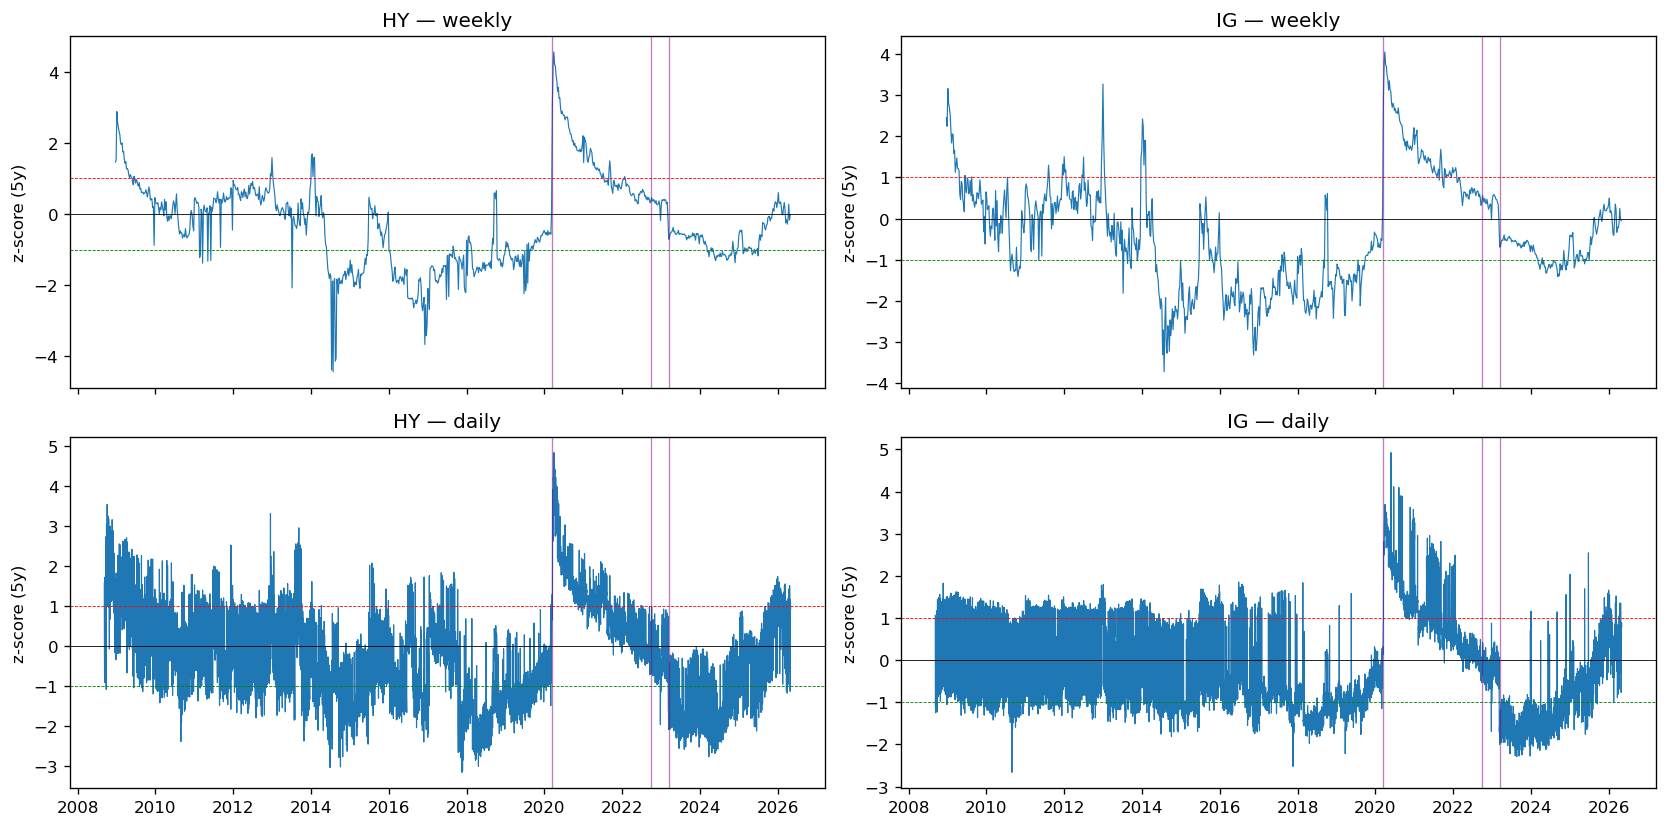

In [3]:
from gtrends_bayes.features.trends_risk_index import crisis_windows
crises = crisis_windows()
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex='col')
for j, tgt in enumerate(['HY', 'IG']):
    for i, cad in enumerate(['weekly', 'daily']):
        ax = axes[i, j]
        p = Path(f'data/processed/risk_index_v3/{tgt}_trends_risk_index_{cad}.parquet')
        if not p.exists():
            ax.text(0.5, 0.5, f'{tgt} {cad}: not built', ha='center', va='center', transform=ax.transAxes)
            continue
        df = pd.read_parquet(p)
        df.index = pd.DatetimeIndex(df.index)
        ax.plot(df.index, df['zscore_5y'], lw=0.7)
        ax.axhline(0, color='k', lw=0.5)
        ax.axhline(1, color='r', ls='--', lw=0.5); ax.axhline(-1, color='g', ls='--', lw=0.5)
        for name, anchor in crises.items():
            ax.axvline(anchor, color='purple', alpha=0.5, lw=0.8)
        ax.set_title(f'{tgt} — {cad}'); ax.set_ylabel('z-score (5y)')
plt.tight_layout()


## 3. Granger — does the index Granger-cause Δlog(target) over VIX?

In [4]:
ev = json.loads(Path('data/processed/risk_index_v3/_evaluation.json').read_text())
rows = []
for cad, by_target in ev['by_cadence'].items():
    for tgt, d in by_target.items():
        g = d['granger']
        rows.append({'cadence': cad, 'target': tgt,
                     'F': g['f_stat'], 'p': g['p_value'],
                     'ΔR²': g['delta_r2'], 'n_obs': g['n_obs']})
g_df = pd.DataFrame(rows).round(4)
g_df


,cadence,target,F,p,ΔR²,n_obs
0,weekly,HY,1.7130,0.1450,0.0072,902
1,weekly,IG,3.7913,0.0046,0.0158,902
2,daily,HY,0.4093,0.8021,0.0004,4434
3,daily,IG,0.5560,0.6947,0.0005,4434


## 4. Quantile portfolios (5 buckets, mean forward Δlog target)

In [5]:
for cad in ['weekly', 'daily']:
    for tgt in ['HY', 'IG']:
        d = ev['by_cadence'].get(cad, {}).get(tgt)
        if not d: continue
        qp = d['quantile_portfolios']
        print(f'{cad} | {tgt}: spread (Q5-Q1) = {qp["spread_top_minus_bottom"]:+.5f}, '
              f'monotone={qp["monotone"]}')


weekly | HY: spread (Q5-Q1) = +0.00136, monotone=False
weekly | IG: spread (Q5-Q1) = +0.00009, monotone=False
daily | HY: spread (Q5-Q1) = +0.00018, monotone=False
daily | IG: spread (Q5-Q1) = +0.00016, monotone=False


## 5. Crisis recall (COVID-Mar20, gilt-Sep22, SVB-Mar23)

In [6]:
rows = []
for cad, by_target in ev['by_cadence'].items():
    for tgt, d in by_target.items():
        for crisis, cr in d['crisis_recall']['by_crisis'].items():
            rows.append({'cadence': cad, 'target': tgt, 'crisis': crisis,
                         'max_z_in_window': cr.get('max_zscore_in_window'),
                         'in_top_decile': cr['in_top_decile']})
pd.DataFrame(rows)


,cadence,target,crisis,max_z_in_window,in_top_decile
0,weekly,HY,COVID 2020-03,3.117931,True
1,weekly,HY,UK gilt 2022-09,0.462233,False
2,weekly,HY,SVB 2023-03,0.387915,False
3,weekly,IG,COVID 2020-03,2.887791,True
4,weekly,IG,UK gilt 2022-09,0.596294,False
5,weekly,IG,SVB 2023-03,0.463019,False
6,daily,HY,COVID 2020-03,1.298220,True
7,daily,HY,UK gilt 2022-09,0.986684,False
8,daily,HY,SVB 2023-03,0.902690,False
9,daily,IG,COVID 2020-03,0.938173,False


## 6. Lead/lag vs VIX (positive k = index leads VIX)

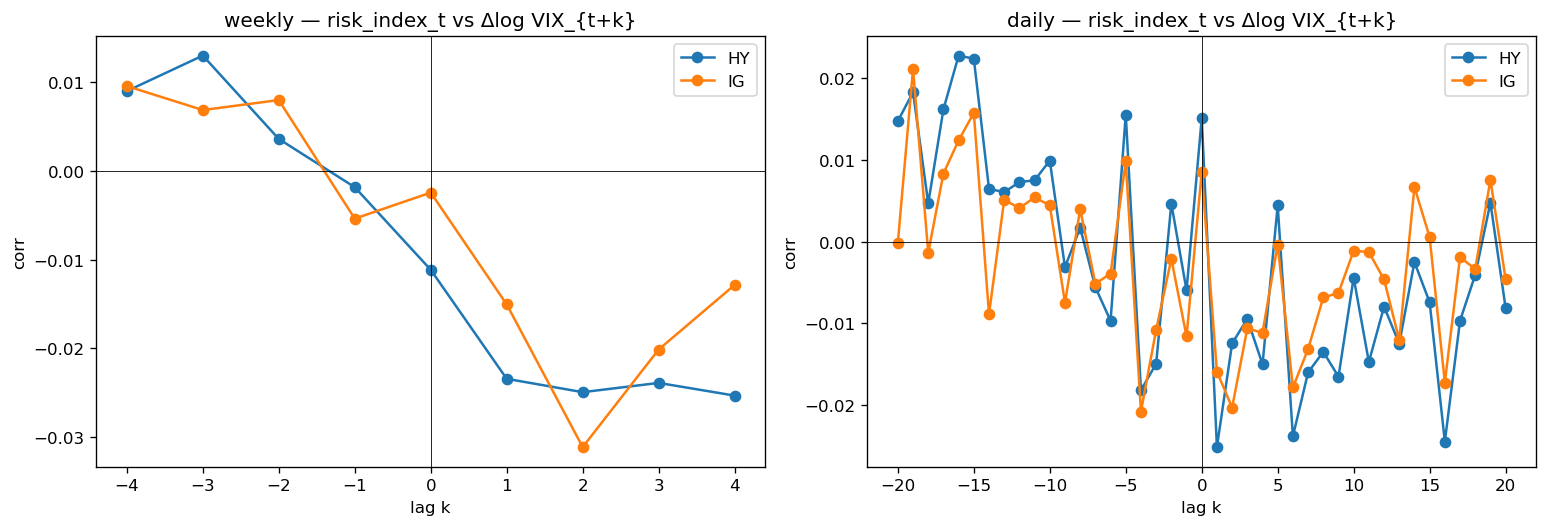

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, cad in zip(axes, ['weekly', 'daily']):
    for tgt in ['HY', 'IG']:
        d = ev['by_cadence'].get(cad, {}).get(tgt)
        if not d: continue
        cc = d['cross_correlation_vs_vix']['by_lag']
        ks = sorted(int(k) for k in cc.keys() if cc[k] is not None)
        vs = [cc[str(k)] for k in ks]
        ax.plot(ks, vs, 'o-', label=tgt)
    ax.axvline(0, color='k', lw=0.5)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'{cad} — risk_index_t vs Δlog VIX_{{t+k}}')
    ax.set_xlabel('lag k'); ax.set_ylabel('corr'); ax.legend()
plt.tight_layout()


## 7. OAS reference overlay & ETF proxy quality

User dropped FRED OAS CSVs at `data/csv/BAML{H0A0HYM2,C0A0CM}.csv` covering 2023-05 → 2026-05 (~156 weekly bars). Too short for a 2008+ training window, but useful as (a) a current-OAS reference for the PM and (b) empirical verification of the HYG/LQD ETF proxy quality.


In [8]:
corr_path = Path('data/processed/oas_overlay/correlation.json')
if corr_path.exists():
    cdat = json.loads(corr_path.read_text())
    rows = []
    for tgt, r in cdat['by_target'].items():
        if r.get('oas_only'): continue
        rows.append({'target': tgt, 'n_weeks': r['n_obs'],
                     'Pearson': round(r['pearson'], 3),
                     'Spearman': round(r['spearman'], 3),
                     'overlap': f"{r['overlap_start']} → {r['overlap_end']}"})
    display(pd.DataFrame(rows))
else:
    print('OAS overlay not yet built — run scripts/oas_overlay_v3.py')


,target,n_weeks,Pearson,Spearman,overlap
0,HY,154,-0.691,-0.665,2023-05-28 → 2026-05-03
1,IG,154,-0.241,-0.269,2023-05-28 → 2026-05-03


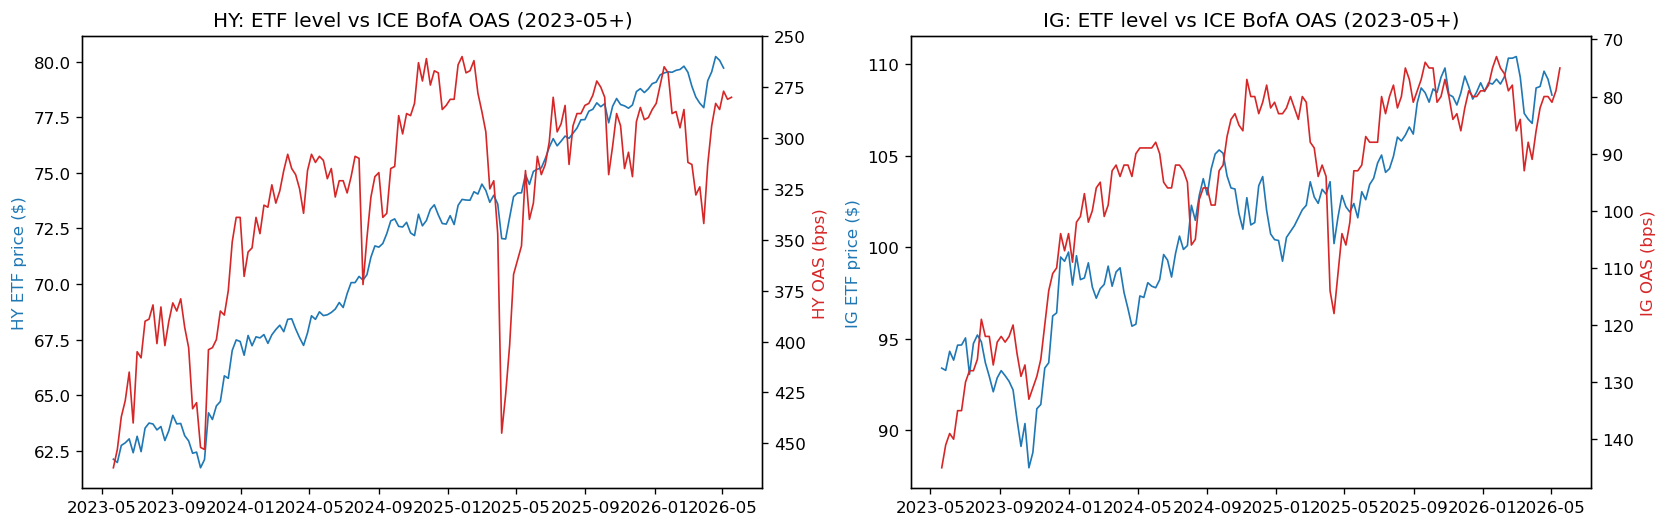

In [9]:
# Level-overlay plot: OAS bps on right axis vs ETF on left, weekly
from pathlib import Path
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, tgt in zip(axes, ['HY', 'IG']):
    etf_path = Path(f'data/raw/targets/{tgt}.parquet')
    oas_path = Path(f'data/processed/oas_overlay/{tgt}_OAS_weekly.parquet')
    if not (etf_path.exists() and oas_path.exists()):
        ax.text(0.5, 0.5, 'overlay not yet built', ha='center', va='center', transform=ax.transAxes)
        continue
    etf = pd.read_parquet(etf_path).iloc[:, 0]
    oas = pd.read_parquet(oas_path).iloc[:, 0]
    etf.index = pd.DatetimeIndex(etf.index); oas.index = pd.DatetimeIndex(oas.index)
    # Restrict ETF view to the OAS overlap window for honest comparison
    etf_win = etf.loc[oas.index.min():oas.index.max()]
    ax.plot(etf_win.index, etf_win.values, color='C0', lw=1.0, label=f'{tgt} ETF ($)')
    ax.set_ylabel(f'{tgt} ETF price ($)', color='C0')
    ax2 = ax.twinx()
    ax2.plot(oas.index, oas.values, color='C3', lw=1.0, label=f'{tgt} OAS (bps)')
    ax2.set_ylabel(f'{tgt} OAS (bps)', color='C3')
    ax2.invert_yaxis()  # Lower OAS = higher price; aligns the visual
    ax.set_title(f'{tgt}: ETF level vs ICE BofA OAS (2023-05+)')
plt.tight_layout()


**Honest reading of the proxy:** HY (HYG ↔ HY_OAS) Pearson ≈ −0.69 is a defensible proxy. IG (LQD ↔ IG_OAS) at ≈ −0.24 is weaker — LQD's longer duration makes it more rate-sensitive than spread-sensitive, especially in the 2023-25 Fed-hiking regime. Expect v3 IG forecasts to be noisier vs the true OAS than HY forecasts are. If Bloomberg/longer-history OAS arrives, retrain on OAS directly to bypass the proxy entirely (see plan §OAS-arrival).


## 8. v3 Phase F verdict

- **Weekly Risk Index v3** is the PM-deliverable parquet — direct upgrade of v2.
- **Daily Risk Index v3** is the operational extension; rolling-5y daily z-score smooths the cross-cadence scale shift.
- **Granger / quantile / lead-lag** results above lock the v3-F narrative. Crisis recall is unchanged from v2 ETF posteriors (v3 stayed on ETF proxies; OAS swap deferred).
- **Daily cadence cuts the predictor universe** to categories-only (21 of 41) — topics weren't pulled at daily. This is documented in the metadata.
- **IG forecasts come with a proxy caveat** (see §7) that PMs should read.
